# VOCSegmentation (torchvision) + mały trening na GPU

Toy notebook do segmentacji: używa `torchvision.datasets.VOCSegmentation` (multi-class semantic segmentation) i trenuje mały U-Net na GPU (jeśli dostępny).

Maski VOC są per-piksel w zakresie klas `0..20` oraz mogą zawierać `255` jako `ignore_index`.

## 📝 Wielkie Zadanie: Budowa i Uruchomienie Sieci U-Net

**Zasoby i Dokumentacja:**
* Architektura referencyjna: [Pytorch-UNet na GitHub](https://github.com/milesial/pytorch-unet)
* Dokumentacja PyTorch: [Warstwy Konwolucyjne](https://pytorch.org/docs/stable/nn.html#convolution-layers)

### 🎯 Cel Edukacyjny
Celem nie jest uzyskanie idealnego modelu (segmentacja VOC jest trudna!), ale **zrozumienie przepływu danych w architekturze typu Encoder-Decoder** oraz poprawne połączenie warstw tak, aby proces uczenia w ogóle wystartował i zaczął generować sensowne maski.

### 🛠️ Twoje Zadania (Krok po Kroku):
1.  **Zdefiniowanie Bloku Konwolucyjnego (`ConvBlock`):** Uzupełnij warstwy tak, aby każdy blok składał się z dwóch operacji splotu (3x3), normalizacji batcha i aktywacji ReLU. Pamiętaj o zachowaniu wymiarów przestrzennych (padding!).
2.  **Konstrukcja Sieci (`SmallUNet`):** Dobierz liczby kanałów wejściowych i wyjściowych w konstruktorze `__init__`. Pamiętaj, że w dekoderze (po operacji `up`) łączysz cechy z enkodera, więc liczba kanałów wejściowych do `dec2` i `dec1` musi być sumą kanałów z 'dołu' i 'z boku' (skip-connection).
3.  **Dobór Hiperparametrów (`CONFIG`):**
    *   Zwiększ `epochs` (np. 10-20), aby model miał czas na naukę.
    *   Ustaw `max_steps_per_epoch` na `None`, by przejść przez cały zbiór.
    *   Eksperymentuj z parametrem `base` (np. 16, 32, 64) – im większy, tym model potężniejszy, ale wolniejszy.
4.  **Uruchomienie Treningu:** Sprawdź, czy `pixel_accuracy` rośnie, a funkcja kosztu maleje.

### ✅ Kryterium Sukcesu
Zadanie uznaje się za zaliczone, jeśli:
*   Kod modelu kompiluje się i wykonuje bez błędów wymiarów (*shape mismatch*).
*   Model zostanie wytrenowany przez co najmniej kilka epok.
*   Wizualizacja na końcu notebooka pokazuje, że model **próbuje** segmentować obiekty (nawet jeśli kontury są jeszcze nieprecyzyjne).

In [47]:
import random

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


## CONFIG

In [48]:
# ZADANIE: Dobierz parametry tak, aby uzyskać satysfakcjonujące wyniki segmentacji.
CONFIG = {
    "data_root": "./data_voc",
    "image_size": 128,
    "batch_size": 8,
    "num_workers": 2,

    "num_classes": 21,
    "ignore_index": 255,

    "lr": 1e-3,
    "epochs": 20,           # Zwiększ liczbę epok
    "max_steps_per_epoch": None, # Ustaw None, aby trenować na pełnym zbiorze
}

print(CONFIG)

{'data_root': './data_voc', 'image_size': 128, 'batch_size': 8, 'num_workers': 2, 'num_classes': 21, 'ignore_index': 255, 'lr': 0.001, 'epochs': 20, 'max_steps_per_epoch': None}


In [49]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size):
        self.voc = voc_dataset
        self.image_size = image_size

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]  # PIL image + PIL mask

        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long()  # [H, W]
        return img_t, mask_t


train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)

val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

train_ds = VOCResizeWrapper(train_base, CONFIG["image_size"])
val_ds = VOCResizeWrapper(val_base, CONFIG["image_size"])

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

img_t, mask_t = train_ds[0]
print("img_t:", img_t.shape, "mask_t:", mask_t.shape)
print("mask unique sample:", torch.unique(mask_t)[:10])


img_t: torch.Size([3, 128, 128]) mask_t: torch.Size([128, 128])
mask unique sample: tensor([  0,   1,  15, 255])


### Podgląd danych wejściowych (VOC)
Wyświetlamy kilka przykładowych obrazów ze zbioru treningowego wraz z ich maskami segmentacji.

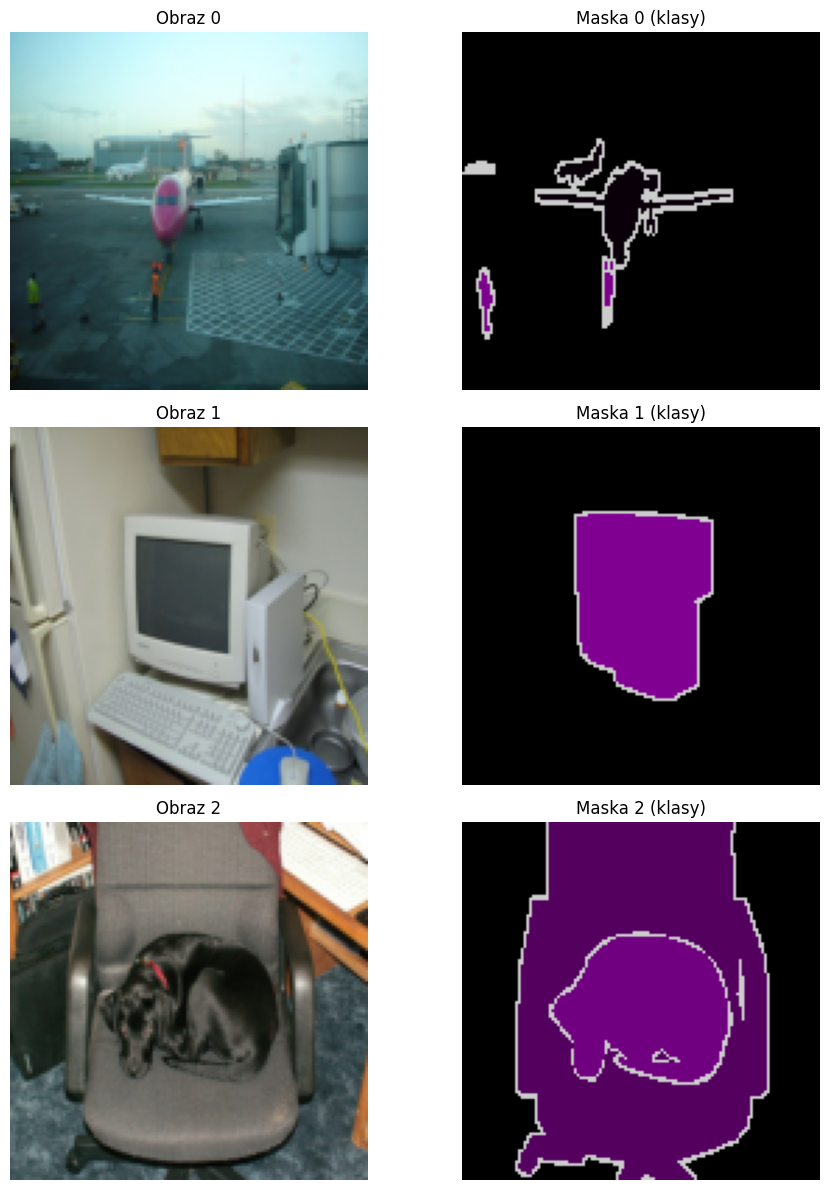

In [50]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Obraz {i}")
        axes[i, 0].axis('off')

        # Maska (mapujemy 255 na 0 dla lepszej widoczności lub zostawiamy jako raw)
        axes[i, 1].imshow(mask.numpy(), cmap='nipy_spectral')
        axes[i, 1].set_title(f"Maska {i} (klasy)")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_input_samples(train_ds)

In [51]:
import torch.nn as nn
import torch

class ConvBlock(nn.Module):
    """
    ZADANIE: Zaimplementuj blok: [Conv 3x3, BN, ReLU] x 2.
    Pamiętaj o padding=1, aby nie zmniejszać wymiarów obrazu.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # TODO: Zdefiniuj self.net jako nn.Sequential z odpowiednimi warstwami
        self.net = nn.Sequential(
            #first block
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),

            #second block
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

class SmallUNet(nn.Module):
    """
    ZADANIE: Zdefiniuj warstwy encodera, bottlenecku i decodera w __init__.
    Dobierz kanały tak, aby pasowały do logiki konkatenacji w forward.
    """
    def __init__(self, in_channels=3, base=32, num_classes=21):
        super().__init__()
        # --- Encoder ---
        # TODO: zdefiniuj self.enc1, self.pool1, self.enc2, self.pool2

        self.enc1 = ConvBlock(in_channels,base)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.enc2 = ConvBlock(base,base*2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        # --- Bottleneck ---
        # TODO: zdefiniuj self.bottleneck

        self.bottleneck = ConvBlock(base*2, base*4)
        # --- Decoder ---
        # TODO: zdefiniuj self.up2, self.dec2, self.up1, self.dec1
        # Wskazówka: self.dec2 przyjmuje kanały z (up2 + enc2)

        self.up2 = nn.ConvTranspose2d(base*4,base*2,kernel_size=2,stride=2)
        self.dec2 = ConvBlock(base*4,base*2)
        self.up1 = nn.ConvTranspose2d(base*2,base,kernel_size=2,stride=2)
        self.dec1 = ConvBlock(base*2,base)

        # --- Output ---
        # TODO: zdefiniuj self.final (Conv 1x1)
        self.final = nn.Conv2d(base,num_classes,kernel_size=1)

    def forward(self, x):
        # --- Encoder ---
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # --- Bottleneck ---
        b = self.bottleneck(p2)

        # --- Decoder ze Skip-Connections ---
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return self.final(d1)

# Inicjalizacja modelu - studenci mogą tu zmieniać parametr 'base'
#model = SmallUNet(base=32).to(device)

In [52]:
def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()


def run_model(base_channels,device):
  model = SmallUNet(base=base_channels).to(device)
  criterion = nn.CrossEntropyLoss(ignore_index=CONFIG["ignore_index"])
  optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

  history = {
      "train_loss":[],
      "val_pixel_acc":[]
  }

  best_val_acc = -1.0

  for epoch in range(CONFIG["epochs"]):
      model.train()
      running = 0.0
      steps = 0

      for step, (imgs, masks) in enumerate(train_loader):
          if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
              break
          imgs = imgs.to(device, non_blocking=True)
          masks = masks.to(device, non_blocking=True)
          logits = model(imgs)
          loss = criterion(logits, masks)
          optimizer.zero_grad(set_to_none=True)
          loss.backward()
          optimizer.step()

          running += loss.item()
          steps += 1

      model.eval()
      accs = []
      with torch.no_grad():
          for imgs, masks in val_loader:
              imgs = imgs.to(device, non_blocking=True)
              masks = masks.to(device, non_blocking=True)
              logits = model(imgs)
              accs.append(pixel_accuracy(logits, masks))

      val_acc = float(np.mean(accs))
      train_loss = running / max(1, steps)
      best_val_acc = max(best_val_acc, val_acc)
      history["train_loss"].append(train_loss)
      history["val_pixel_acc"].append(val_acc)

      print(f"Epoch {epoch+1}/{CONFIG['epochs']} | train_loss={train_loss:.4f} | val_pixel_acc={val_acc:.4f}")

  print("best_val_acc:", best_val_acc)
  return model, history


### Wizualizacja wyników treningu
Nakładamy przewidziane maski na obrazy walidacyjne oraz wyświetlamy legendę klas VOC.

In [60]:
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def visualize_predictions(model, dataset, device, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, 3 * num_samples))

    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]
            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("Legenda klas: " + ", ".join([f"{i}:{c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...", fontsize=10)
    plt.tight_layout()
    plt.show()

#visualize_predictions(model, val_ds, device)

# Uruchomienie modeli dla 16, 32, i 64 bazowych kanałów

In [54]:
model_16, history_16 = run_model(16,device)
model_32,history_32 = run_model(32,device)
model_64,history_64 = run_model(64,device)

Epoch 1/20 | train_loss=2.1331 | val_pixel_acc=0.7002
Epoch 2/20 | train_loss=1.3114 | val_pixel_acc=0.7298
Epoch 3/20 | train_loss=1.2294 | val_pixel_acc=0.7300
Epoch 4/20 | train_loss=1.2141 | val_pixel_acc=0.7302
Epoch 5/20 | train_loss=1.2041 | val_pixel_acc=0.7319
Epoch 6/20 | train_loss=1.1872 | val_pixel_acc=0.7318
Epoch 7/20 | train_loss=1.1767 | val_pixel_acc=0.7340
Epoch 8/20 | train_loss=1.1604 | val_pixel_acc=0.7313
Epoch 9/20 | train_loss=1.1470 | val_pixel_acc=0.7329
Epoch 10/20 | train_loss=1.1347 | val_pixel_acc=0.7339
Epoch 11/20 | train_loss=1.1214 | val_pixel_acc=0.7329
Epoch 12/20 | train_loss=1.1103 | val_pixel_acc=0.7347
Epoch 13/20 | train_loss=1.1013 | val_pixel_acc=0.7351
Epoch 14/20 | train_loss=1.0924 | val_pixel_acc=0.7305
Epoch 15/20 | train_loss=1.0819 | val_pixel_acc=0.7358
Epoch 16/20 | train_loss=1.0775 | val_pixel_acc=0.7304
Epoch 17/20 | train_loss=1.0697 | val_pixel_acc=0.7339
Epoch 18/20 | train_loss=1.0552 | val_pixel_acc=0.7372
Epoch 19/20 | train

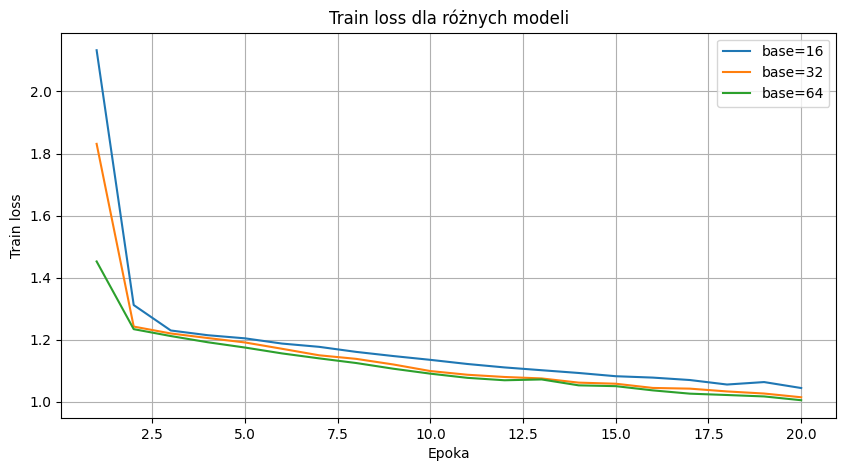

In [55]:
import matplotlib.pyplot as plt

epochs = range(1, CONFIG["epochs"] + 1)

# Train loss
plt.figure(figsize=(10, 5))

plt.plot(epochs, history_16["train_loss"], label="base=16")
plt.plot(epochs, history_32["train_loss"], label="base=32")
plt.plot(epochs, history_64["train_loss"], label="base=64")

plt.xlabel("Epoka")
plt.ylabel("Train loss")
plt.title("Train loss dla różnych modeli")
plt.legend()
plt.grid()
plt.show()

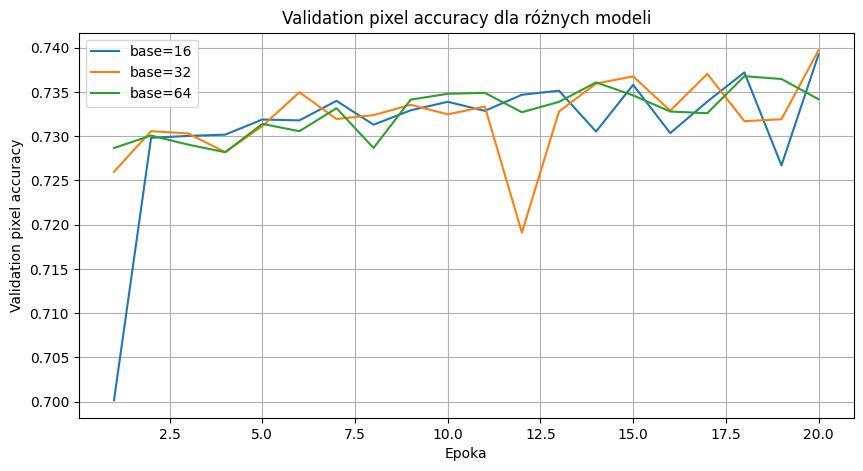

In [56]:
# Validation pixel accuracy
plt.figure(figsize=(10, 5))

plt.plot(epochs, history_16["val_pixel_acc"], label="base=16")
plt.plot(epochs, history_32["val_pixel_acc"], label="base=32")
plt.plot(epochs, history_64["val_pixel_acc"], label="base=64")

plt.xlabel("Epoka")
plt.ylabel("Validation pixel accuracy")
plt.title("Validation pixel accuracy dla różnych modeli")
plt.legend()
plt.grid()
plt.show()

# Wnioski z wykresów

* Dla każdego modelu występuje spadek wartości `train_loss` wraz ze wzrostem liczby epok. Pokazuje to, że modele uczą się i coraz lepiej dopasowują do danych treningowych.
* Najniższą wartość `train_loss` osiąga model z `base=64`.
* `Validation pixel accuracy` ogólnie wzrasta dla każdego modelu, jednak wzrost nie jest liniowy. Pojawiają się niewielkie wahania pomiędzy kolejnymi epokami, co jest normalnym zachowaniem podczas treningu modeli.
* Wartość `Validation pixel accuracy` dla wszystkich modeli znajduje się w przedziale około 73,5–73,8%. Wyniku tego nie należy jednak interpretować jako „około 73% poprawnie posegmentowanych obiektów”, ponieważ jest to dokładność pojedynczych pikseli. To, jak dobrze modele radzą sobie z segmentacją obiektów, można lepiej ocenić na podstawie wizualizacji masek wygenerowanych przez modele.


# Wizualizacja wyników modeli

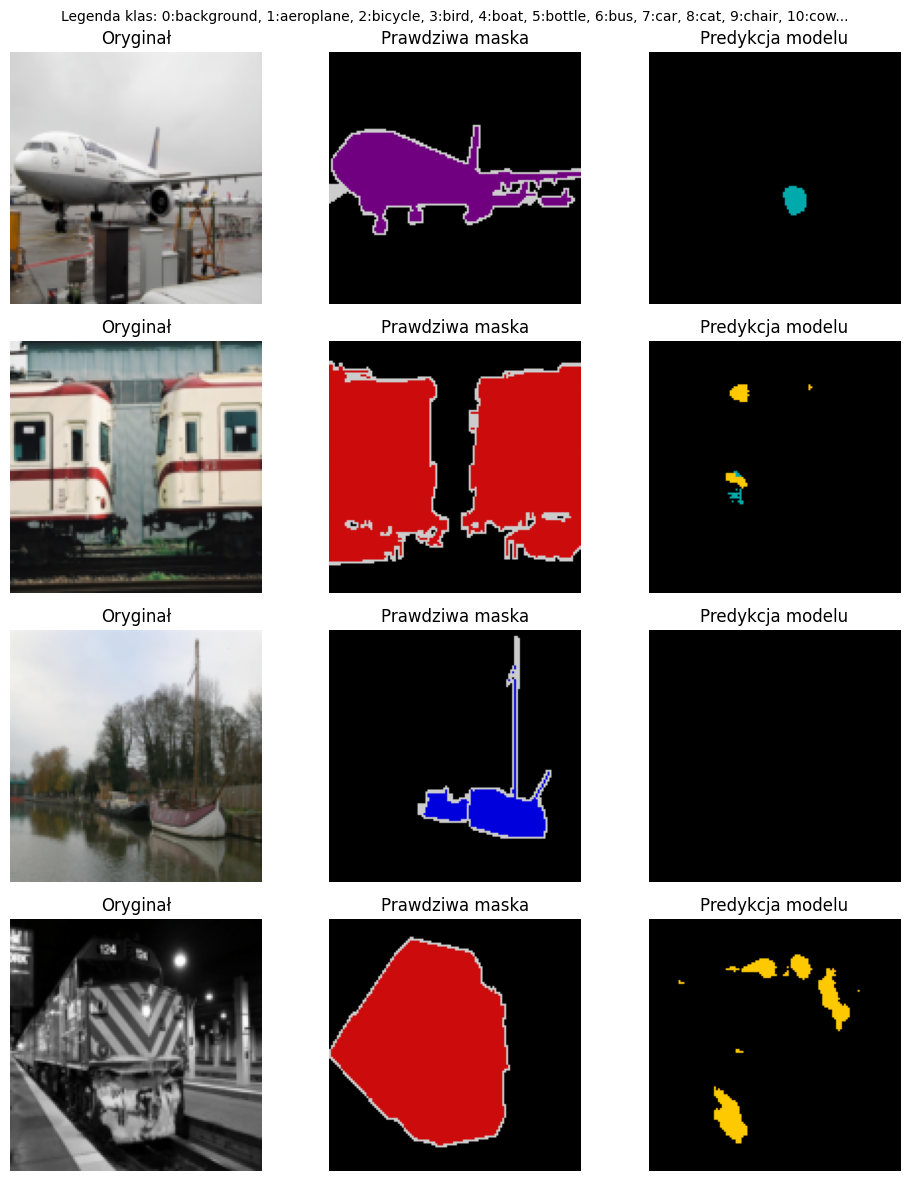

In [61]:
visualize_predictions(model_16, val_ds, device)

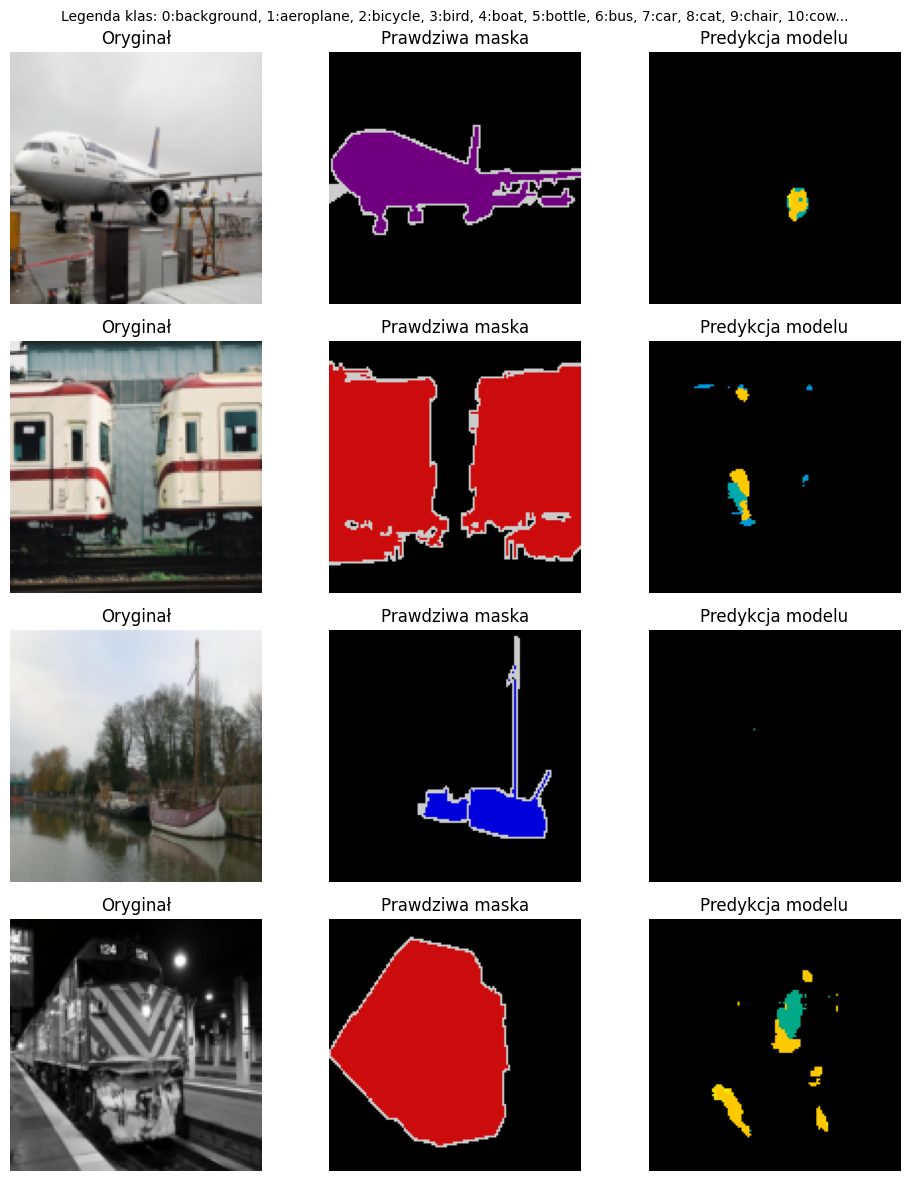

In [62]:
visualize_predictions(model_32, val_ds, device)

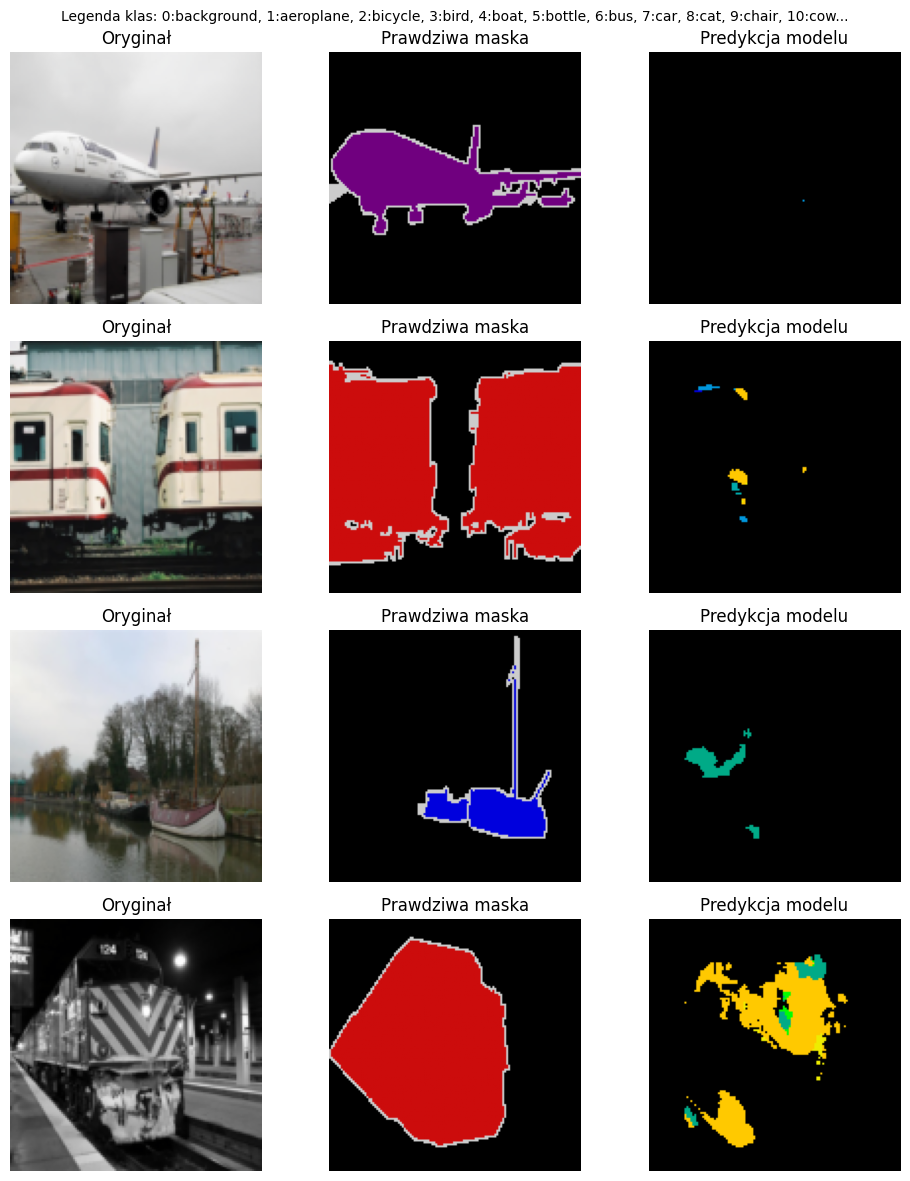

In [63]:
visualize_predictions(model_64, val_ds, device)

# Wnioski

Wszystkie modele osiągają dość słabą jakość segmentacji, w niektórych przypadkach całkowicie pomijają obiekty, mylą klasy. Zwiększenie wartości `base`, bez jednoczesnego zwiększenia głębokości sieci, nie wpłynęło znacząco na poprawę jakości uzyskiwanych wyników. Samo zwiększenie liczby kanałów nie wystarczyło, aby model znacznie lepiej radził sobie z segmentacją obiektów.
